# Imports

In [1]:
import math
import os
import sys

import numpy as np
import torch
from torchvision.transforms import GaussianBlur
from IPython.core.pylabtools import figsize
from mpmath.identification import transforms
import matplotlib.pyplot as plt
from torchvision.transforms.v2 import RandomApply

from utils.checkpoint import load_checkpoint, save_checkpoint, load_model
from utils.data import get_dataloaders, get_img_from_loader
from evaluate import evaluate, evaluate_with_uncertainty

sys.path.append("..")

from models.lenet import Net as LeNet
from config import Config

from utils.corruptions import gaussian_blur, test_on_corruptions, corruptions_uncertainty
from utils.data import get_img_from_loader



In [2]:
config = Config()
device = config.device

# Prepare data
_, val_loader, test_loader = get_dataloaders(
    data_dir="../data",
    batch_size=config.test_batch_size,
    num_workers=config.num_workers,
    use_cuda=torch.cuda.is_available(),
    dataset='EMNIST',
    dataset_kwargs={"split": "letters"},
)

# Model
lenet_model = LeNet(
    prior_sigma1=math.exp(-0.8470609173270909),
    prior_sigma2=math.exp(-7.293222293379696),
    prior_pi=0.44622172885322486,
    num_classes=26,
    rho_init=-5.724956071835678
).to(device)

# Optimizer (needed to load checkpoint)
optimizer = torch.optim.Adam(lenet_model.parameters(), lr=config.learning_rate)
# Load weights
# config.model_name = 'mnist_bayesian_lenet'
config.model_name = 'lenet_emnist_lrp9p426em04_logprior1mp847_logprior2m7p293_priorpip446_rhoinit_m5p724_batch_64_v1'
load_model(lenet_model, f'{config.checkpoint_path}/{config.model_name}/{config.model_name}_20260317.pth', device)

[model] Loaded from ../checkpoints/lenet_emnist_lrp9p426em04_logprior1mp847_logprior2m7p293_priorpip446_rhoinit_m5p724_batch_64_v1/lenet_emnist_lrp9p426em04_logprior1mp847_logprior2m7p293_priorpip446_rhoinit_m5p724_batch_64_v1_20260317.pth


# Evaluate

In [3]:
from train import test

loss, accuracy = test(lenet_model, test_loader, device, 0)
print(f"Loss: {loss:.6f}, Accuracy: {accuracy:.4f}")

Loss: 6.685663, Accuracy: 0.9223



Expected Calibration Error: 0.0115


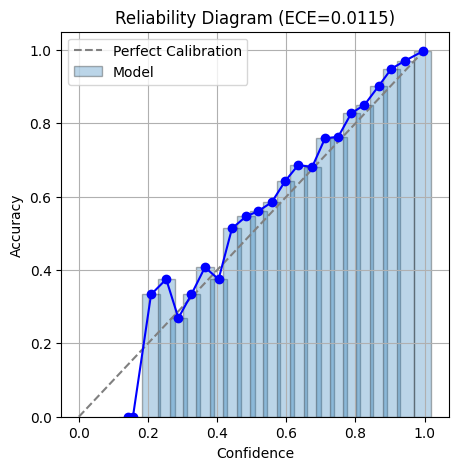

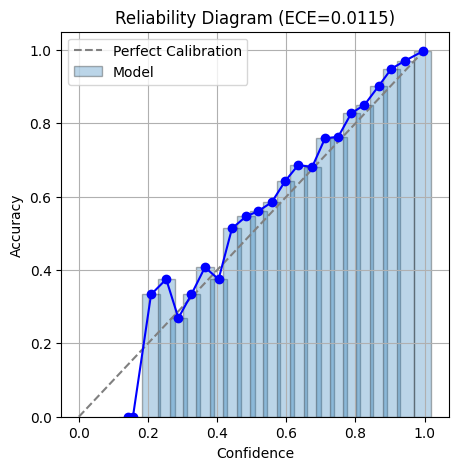

In [4]:
from utils.calibration import reliability_diagram
reliability_diagram(lenet_model, test_loader, device, T=20, n_bins=26, num_classes=26)

In [5]:
from evaluate import evaluate_with_uncertainty

preds, (total, alea, epis) = evaluate_with_uncertainty(lenet_model, test_loader, device, mc_samples=20)
print(f"Total Uncertainty (mean): {total.mean().item()}")
print(f"Aleatoric (mean): {alea.mean().item()}")
print(f"Epistemic (mean): {epis.mean().item()}")

Total Uncertainty (mean): 0.10713978856801987
Aleatoric (mean): 0.08429049700498581
Epistemic (mean): 0.022849293425679207


In [4]:
corruptions = {
    'Original': lambda x: x,
    # 'WeakBlur': lambda x: gaussian_blur(x, kernel_size=3),
    'MediumBlur': lambda x: gaussian_blur(x, kernel_size=5),
    # 'StrongBlur': lambda x: gaussian_blur(x, kernel_size=7),
    'VeryStrongBlur': lambda x: gaussian_blur(x, kernel_size=9),
}

In [7]:
letters_map = {i: chr(97 + i) for i in range(26)}

Random batch index: 1394, image index: 12
IMG[1394, 12]=y


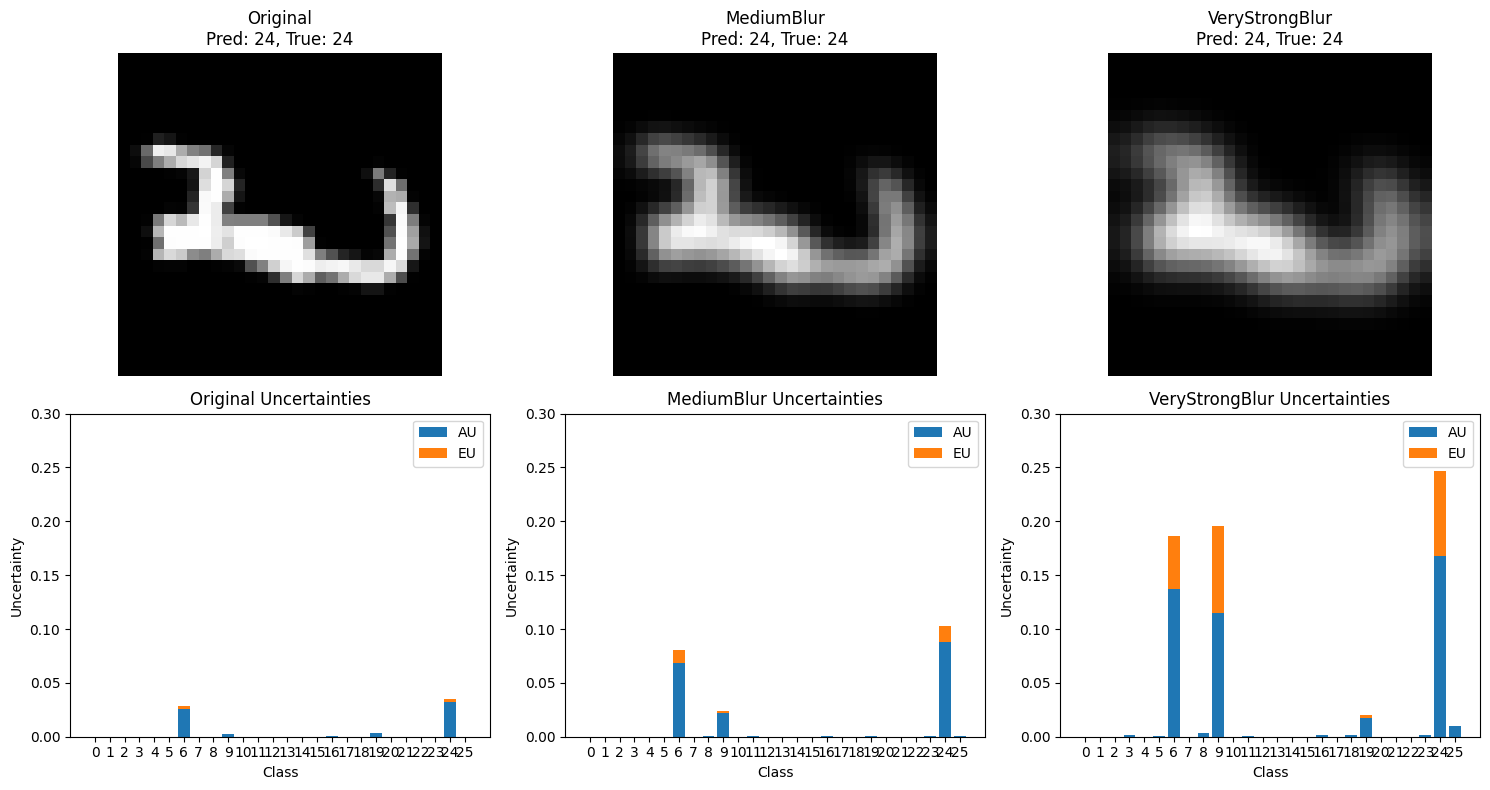

In [11]:
import random

rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
img, label = get_img_from_loader(test_loader, batch_idx=rand_batch_idx, img_idx=rand_img_idx, device=config.device)
print(f'IMG[{rand_batch_idx}, {rand_img_idx}]={letters_map[label.item()]}')
corruptions_uncertainty(lenet_model, img, label, corruptions, num_classes=26, T=20)

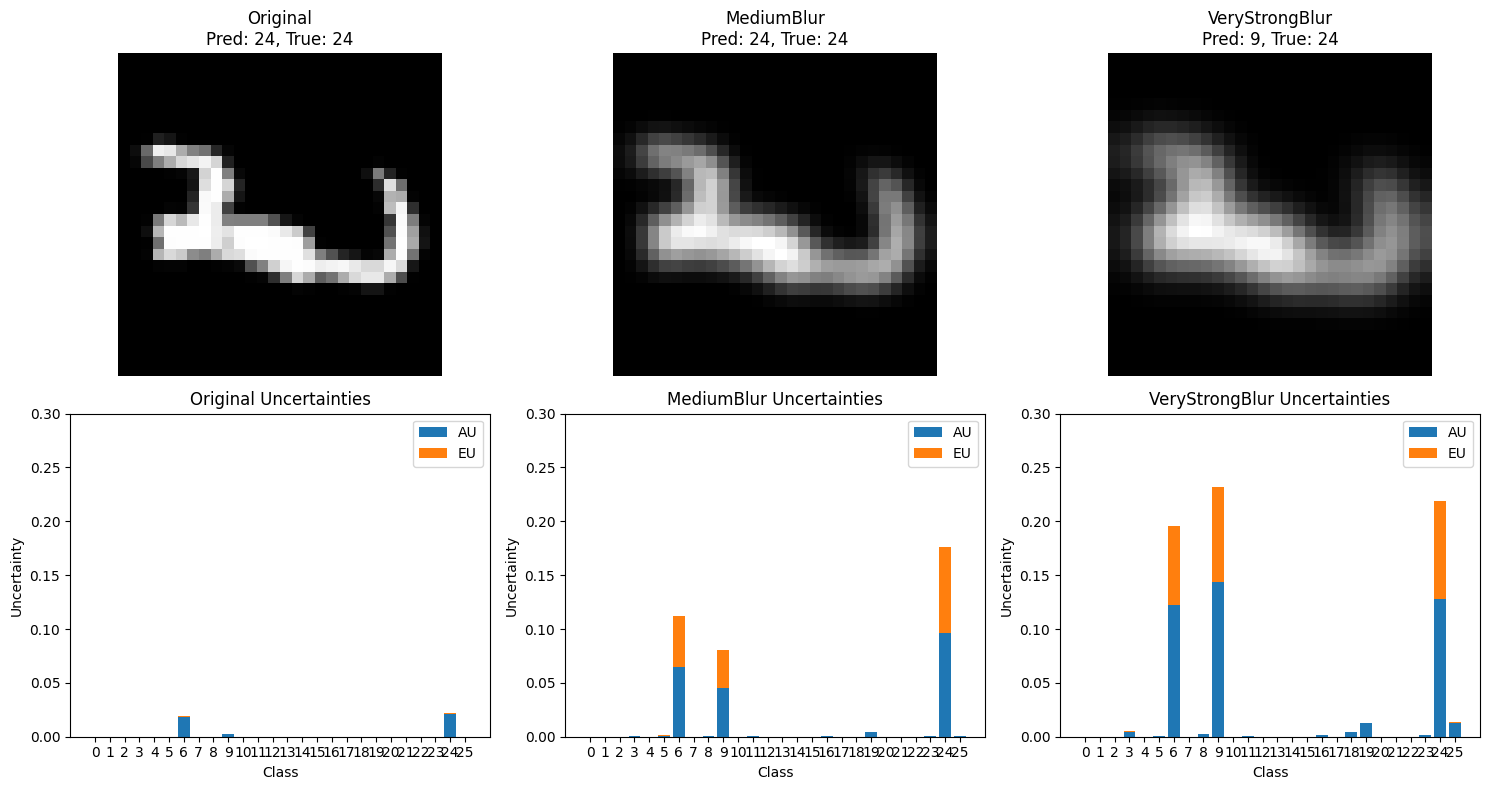

In [12]:
img, label = get_img_from_loader(test_loader, batch_idx=1394, img_idx=12, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, num_classes=26, T=20)

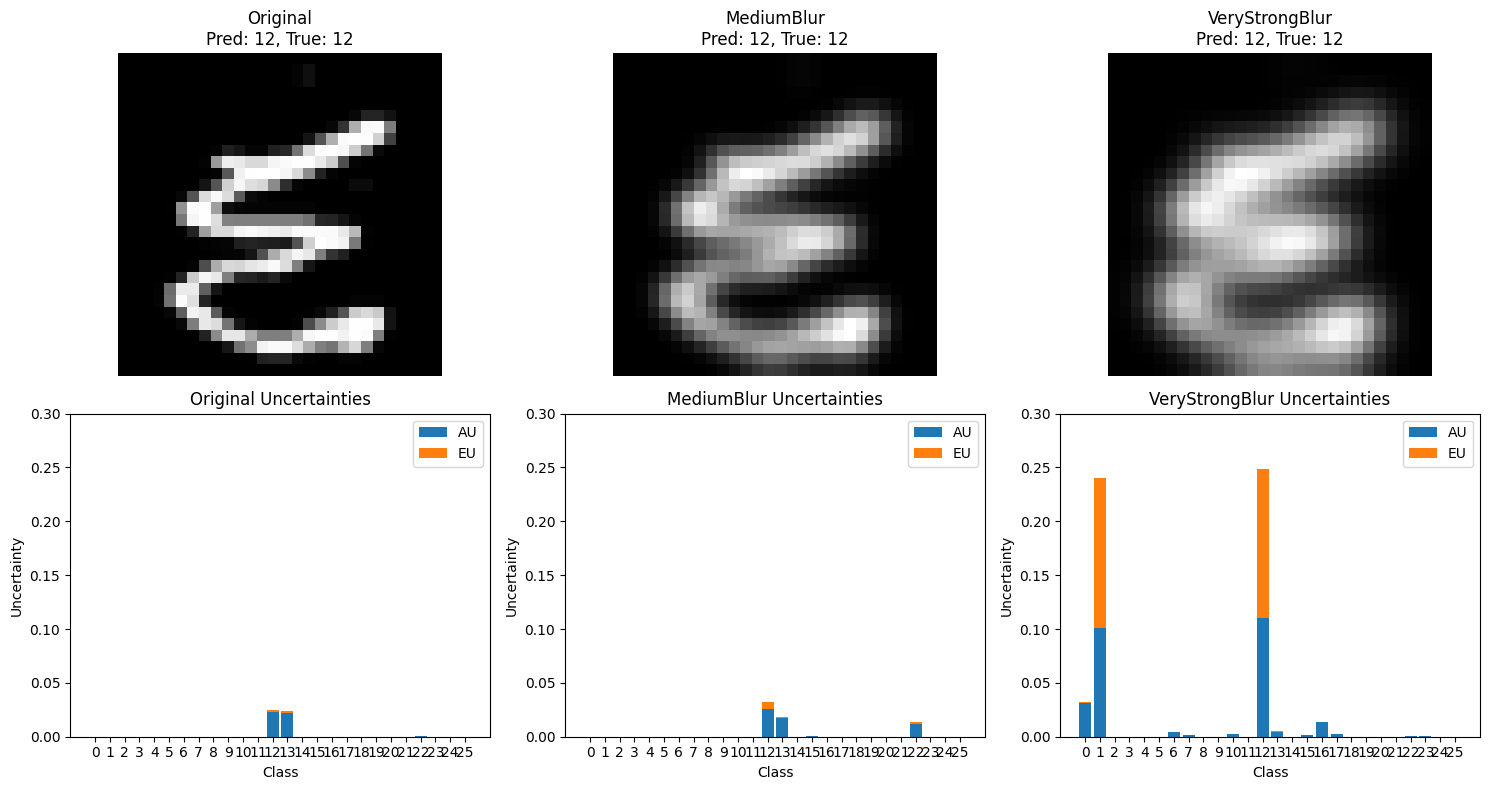

In [5]:
img, label = get_img_from_loader(test_loader, batch_idx=717, img_idx=1, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, num_classes=26, T=20)

# Зависимость неопределенности модели от правильности предсказаний

In [13]:
# Анализ корреляции между неопределенностью и правильностью предсказаний для разных уровней размытия
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision.transforms import GaussianBlur
from utils.uncertainty import mc_predict, quantify_uncertainties

T = 20
kernel_sizes = [0, 1, 3, 5, 7, 9]
# kernel_sizes = [0, 1, 3, 7]
correlations = []
mean_unc_correct = []
mean_unc_incorrect = []
mean_aunc_correct = []
mean_aunc_incorrect = []
mean_eunc_correct = []
mean_eunc_incorrect = []

lenet_model.eval()

for ks in kernel_sizes:
    if ks == 0:
        current_loader = test_loader
        desc = "Original"
    else:
        current_loader = get_dataloaders(
            data_dir="../data",
            batch_size=config.test_batch_size,
            num_workers=config.num_workers,
            use_cuda=torch.cuda.is_available(),
            extra_transforms=[GaussianBlur(ks)]
        )[2]
        desc = f"Blur {ks}"

    all_correct = []
    all_conf = []
    all_uncertainties = []
    all_aleatoric = []
    all_epistemic = []

    print(f"Processing {desc}...")
    for x, y in tqdm(current_loader, leave=False):
        x, y = x.to(device), y.to(device)
        
        # Оценка неопределенности
        mc_preds = mc_predict(lenet_model, x, mc_samples=T)
        preds, (total_unc_mat, alea_unc_mat, _) = quantify_uncertainties(mc_preds)
        
        # Извлекаем диагональ (дисперсию для каждого класса) и суммируем
        unc = total_unc_mat.diagonal(dim1=1, dim2=2).sum(-1)
        aunc = alea_unc_mat.diagonal(dim1=1, dim2=2).sum(-1)
        correct = (preds == y).float()
        
        # Softmax probability of the predicted class (mean over MC samples)
        mean_probs = mc_preds.mean(0)  # [batch, num_classes]
        pred_conf = mean_probs[torch.arange(len(preds)), preds]  # [batch]
        true_conf = mean_probs[torch.arange(len(y)), y]  # [batch]

        all_correct.append(correct.cpu().numpy())
        all_conf.append(true_conf.cpu().numpy())
        all_uncertainties.append(unc.cpu().numpy())
        all_aleatoric.append(aunc.cpu().numpy())
        all_epistemic.append((unc - aunc).cpu().numpy())

    c_vec = np.concatenate(all_correct)
    conf_vec = np.concatenate(all_conf)
    u_vec = np.concatenate(all_uncertainties)
    au_vec = np.concatenate(all_aleatoric)
    eu_vec = np.concatenate(all_epistemic)
    eunc_mean = np.mean(eu_vec)
    aunc_mean = np.mean(au_vec)
    print(f"Kernel {ks}: E[epistemic]={eunc_mean:.6f}, E[aleatoric]={aunc_mean:.6f}, ratio={eunc_mean/aunc_mean:.4f}")

    # Считаем корреляцию (softmax confidence of predicted class vs uncertainty)
    corr = np.corrcoef(conf_vec, u_vec)[0, 1]
    correlations.append(corr)
    
    # Считаем среднюю неопределенность для верных и неверных ответов
    mean_unc_correct.append(u_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    mean_unc_incorrect.append(u_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)
    mean_aunc_correct.append(au_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    mean_aunc_incorrect.append(au_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)
    mean_eunc_correct.append(eu_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    mean_eunc_incorrect.append(eu_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)

Processing Original...


Kernel 0: E[epistemic]=0.022852, E[aleatoric]=0.084171, ratio=0.2715
Processing Blur 1...


Kernel 1: E[epistemic]=0.138901, E[aleatoric]=0.340363, ratio=0.4081
Processing Blur 3...


Kernel 3: E[epistemic]=0.139006, E[aleatoric]=0.335167, ratio=0.4147
Processing Blur 5...


Kernel 5: E[epistemic]=0.147272, E[aleatoric]=0.348371, ratio=0.4227
Processing Blur 7...


Kernel 7: E[epistemic]=0.150736, E[aleatoric]=0.355789, ratio=0.4237
Processing Blur 9...


Kernel 9: E[epistemic]=0.151762, E[aleatoric]=0.358357, ratio=0.4235


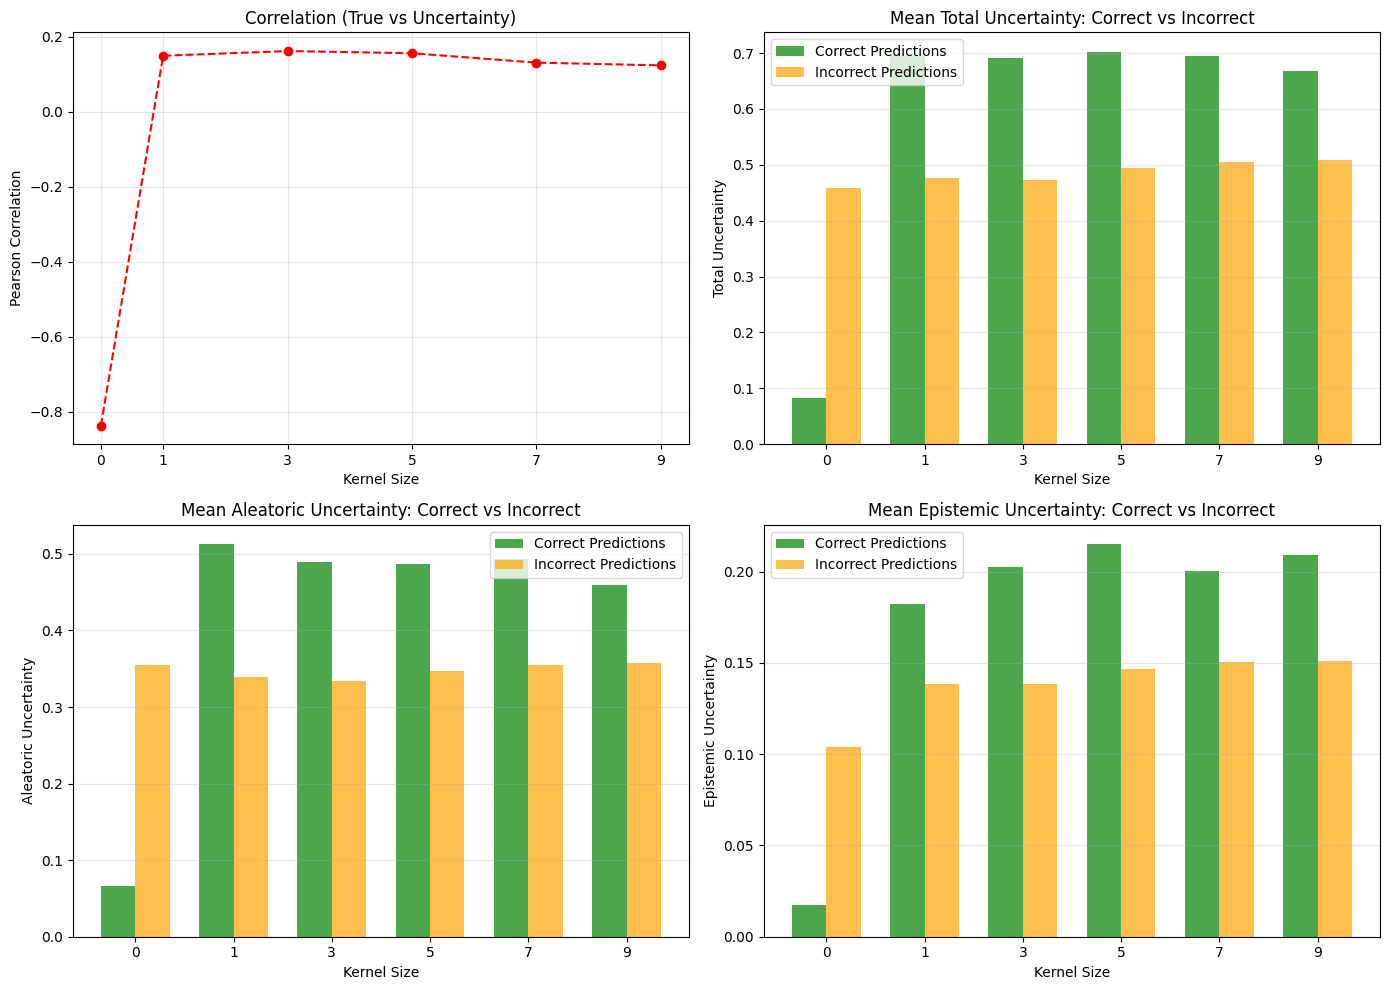

Kernel 0: Correlation = -0.8361, Unc Ratio (Err/Corr) = 5.49x
	Alea Unc Ratio (Err/Corr) = 5.36x, Unc Ratio (Err/Corr) = 5.97x
Kernel 1: Correlation = 0.1495, Unc Ratio (Err/Corr) = 0.69x
	Alea Unc Ratio (Err/Corr) = 0.66x, Unc Ratio (Err/Corr) = 0.76x
Kernel 3: Correlation = 0.1621, Unc Ratio (Err/Corr) = 0.68x
	Alea Unc Ratio (Err/Corr) = 0.68x, Unc Ratio (Err/Corr) = 0.68x
Kernel 5: Correlation = 0.1562, Unc Ratio (Err/Corr) = 0.70x
	Alea Unc Ratio (Err/Corr) = 0.71x, Unc Ratio (Err/Corr) = 0.68x
Kernel 7: Correlation = 0.1312, Unc Ratio (Err/Corr) = 0.73x
	Alea Unc Ratio (Err/Corr) = 0.72x, Unc Ratio (Err/Corr) = 0.75x
Kernel 9: Correlation = 0.1239, Unc Ratio (Err/Corr) = 0.76x
	Alea Unc Ratio (Err/Corr) = 0.78x, Unc Ratio (Err/Corr) = 0.72x


In [15]:
# Визуализация результатов
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x_labels = [str(k) for k in kernel_sizes]
x = np.arange(len(kernel_sizes))
titles = ['Total', 'Aleatoric', 'Epistemic']
incorrect = [mean_unc_incorrect, mean_aunc_incorrect, mean_eunc_incorrect]
correct = [mean_unc_correct, mean_aunc_correct, mean_eunc_correct]

# График 1: Коэффициент корреляции
axes[0, 0].plot(kernel_sizes, correlations, marker='o', color='red', linestyle='--')
axes[0, 0].set_title("Correlation (True vs Uncertainty)")
axes[0, 0].set_xticks(kernel_sizes)
axes[0, 0].set_xlabel("Kernel Size")
axes[0, 0].set_ylabel("Pearson Correlation")
axes[0, 0].grid(True, alpha=0.3)

# График 2: Сравнение неопределенности для Correct vs Incorrect
for i, ax in enumerate(axes.flatten()[1:]):
    width = 0.35
    ax.bar(x - width/2, correct[i], width, label='Correct Predictions', color='green', alpha=0.7)
    ax.bar(x + width/2, incorrect[i], width, label='Incorrect Predictions', color='orange', alpha=0.7)
    ax.set_title(f"Mean {titles[i]} Uncertainty: Correct vs Incorrect")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel("Kernel Size")
    ax.set_ylabel(f"{titles[i]} Uncertainty")
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

for i, ks in enumerate(kernel_sizes):
    print(f"Kernel {ks}: Correlation = {correlations[i]:.4f}, Unc Ratio (Err/Corr) = {mean_unc_incorrect[i]/mean_unc_correct[i]:.2f}x")
    print(f"\tAlea Unc Ratio (Err/Corr) = {mean_aunc_incorrect[i]/mean_aunc_correct[i]:.2f}x, Unc Ratio (Err/Corr) = {mean_eunc_incorrect[i]/mean_eunc_correct[i]:.2f}x")


In [ ]:
for name, module in lenet_model.named_modules():
    if hasattr(module, 'weight_sigma'):  # или как у тебя называется параметр
        sigma = module.weight_sigma
        # если используется rho-параметризация: sigma = log(1 + exp(rho))
        print(f"{name}: mean(sigma) = {sigma.mean().item():.6f}, max(sigma) = {sigma.max().item():.6f}")